# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

In [2]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [3]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [4]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

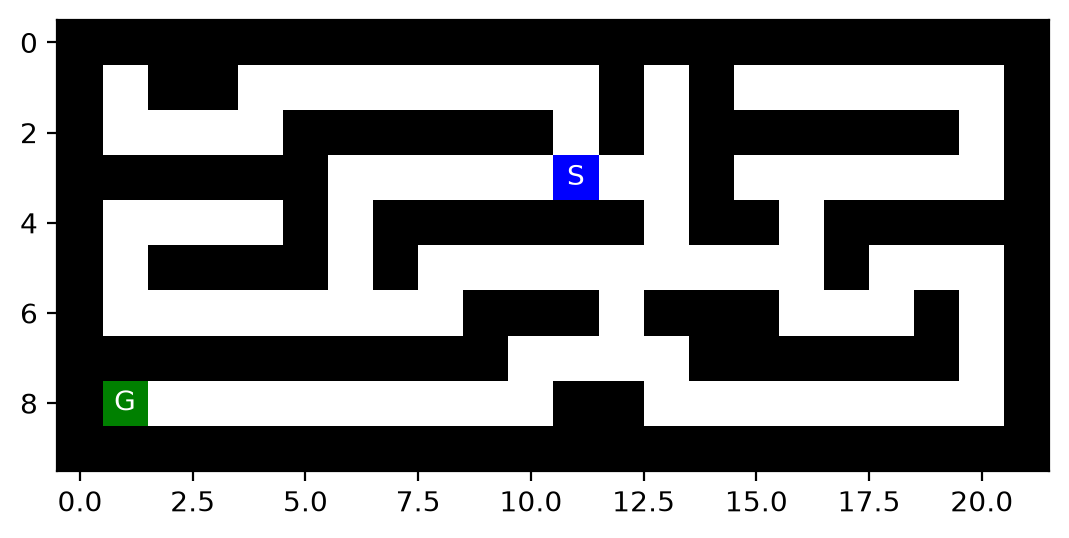

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [6]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [7]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

        Para

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [8]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [9]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['E', 'W', 'N', 'W', 'S', 'N', 'N', 'W', 'N', 'W']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [10]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: W
Following plan... step 1: W
Following plan... step 2: W
Following plan... step 3: N
Following plan... step 4: W
Following plan... step 5: W
Following plan... step 6: E
Following plan... step 7: E
Following plan... step 8: E
Following plan... step 9: N
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [11]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

In [23]:
import numpy as np
import collections
import maze_helper as mh
import heapq
import matplotlib.pyplot as plt
import pandas as pd

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

Định nghĩa các thành phần của bài toán tìm kiếm:

* **Trạng thái ban đầu (Initial state)**: Vị trí xuất phát $S$ của tác nhân trong mê cung, biểu diễn dưới dạng tọa độ `(row, col)`.
* **Hành động (Actions)**: Tập hợp các di chuyển hợp lệ sang các ô lân cận không phải là tường (`X`). Các hành động có thể là đi lên Bắc (`N`), đi sang Đông (`E`), đi xuống Nam (`S`), đi sang Tây (`W`).
* **Mô hình chuyển trạng thái (Transition model)**: Nhận vào một trạng thái hiện tại $s$ và một hành động $a$, trả về trạng thái kế tiếp $s'$ tương ứng với tọa độ mới sau khi di chuyển một ô theo hướng hành động.
* **Trạng thái đích (Goal state)**: Vị trí đích $G$ trong mê cung mà tác nhân cần đạt đến.
* **Chi phí đường đi (Path cost)**: Tổng số bước di chuyển từ trạng thái ban đầu đến trạng thái hiện tại. Mỗi bước di chuyển từ ô này sang ô liền kề có chi phí là $1$.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

Ước lượng kích thước bài toán:

* $n$: kích thước không gian trạng thái (số lượng ô trống có thể đi được trong mê cung).
* $d$: độ sâu của lời giải tối ưu (số bước đi ngắn nhất từ xuất phát đến đích).
* $m$: độ sâu tối đa của cây tìm kiếm.
* $b$: hệ số nhánh tối đa (hệ số nhánh lớn nhất có thể có tại một ô, tối đa là 4 hướng di chuyển).

**Cách xác định cho một mê cung cụ thể:**
- $n$: Đếm tổng số ô trống (`' '`), `'S'`, và `'G'` trong mảng mê cung.
- $d$: Số bước trong đường đi ngắn nhất tìm được bởi thuật toán BFS.
- $m$: Số ô trống lớn nhất mà một đường đi không tự trùng lặp có thể đi qua.
- $b$: Số hướng di chuyển tối đa không gặp tường từ bất kỳ ô trống nào (tối đa là 4, tối thiểu là 0).

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [ ]:
def get_neighbors(maze, pos):
    r, c = pos
    directions = {
        'N': (r - 1, c),
        'S': (r + 1, c),
        'E': (r, c + 1),
        'W': (r, c - 1)
    }
    neighbors = []
    for action, (nr, nc) in directions.items():
        if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
            if maze[nr, nc] != 'X':
                neighbors.append(((nr, nc), action))
    return neighbors

def bfs(maze, start, goal):
    start_node = Node(start, None, None, 0)
    if start == goal:
        return start_node, 0, 0, 1

    frontier = collections.deque([start_node])
    reached = {start: start_node}

    nodes_expanded = 0
    max_depth = 0
    max_frontier_size = 1

    while frontier:
        max_frontier_size = max(max_frontier_size, len(frontier))
        node = frontier.popleft()
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, nodes_expanded, max_depth, max_frontier_size

        for neighbor_pos, action in get_neighbors(maze, node.pos):
            if neighbor_pos not in reached:
                child = Node(neighbor_pos, node, action, node.cost + 1)
                reached[neighbor_pos] = child
                frontier.append(child)

    return None, nodes_expanded, max_depth, max_frontier_size

def dfs(maze, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = [start_node]

    nodes_expanded = 0
    max_depth = 0
    max_frontier_size = 1

    while frontier:
        max_frontier_size = max(max_frontier_size, len(frontier))
        node = frontier.pop()
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, nodes_expanded, max_depth, max_frontier_size

        # Kiểm tra chu trình trên đường đi từ nút gốc đến nút hiện tại
        curr = node
        cycle = False
        while curr.parent is not None:
            if curr.parent.pos == node.pos:
                cycle = True
                break
            curr = curr.parent

        if cycle:
            continue

        for neighbor_pos, action in get_neighbors(maze, node.pos):
            # Tránh lặp ngay lập tức tổ tiên trực tiếp
            if node.parent and neighbor_pos == node.parent.pos:
                continue
            child = Node(neighbor_pos, node, action, node.cost + 1)
            frontier.append(child)

    return None, nodes_expanded, max_depth, max_frontier_size

How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

### BFS và DFS giải quyết các vòng lặp (chu trình) như thế nào?

- **BFS**: Sử dụng tập hợp `reached` để lưu trữ tất cả các trạng thái đã đi qua. Khi gặp một trạng thái đã nằm trong `reached`, BFS sẽ bỏ qua không đưa vào frontier nữa, do đó loại bỏ hoàn toàn khả năng bị lặp vô hạn do vòng lặp.
- **DFS**: Vì không sử dụng tập hợp `reached` để tối ưu bộ nhớ, DFS kiểm tra chu trình bằng cách lần mò ngược về các nút cha (tổ tiên) thông qua con trỏ `parent`. Nếu trạng thái kế tiếp đã xuất hiện trên đường đi hiện tại từ gốc, nó sẽ bỏ qua để tránh lặp vô hạn.

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

- **BFS**:
  - *Hoàn chỉnh (Complete)*: Có (trong không gian trạng thái hữu hạn).
  - *Tối ưu (Optimal)*: Có (vì chi phí mỗi bước là đồng nhất bằng 1).
  - *Độ phức tạp thời gian*: $O(b^d)$
  - *Độ phức tạp không gian*: $O(b^d)$ do phải lưu trữ danh sách frontier và reached.
- **DFS**:
  - *Hoàn chỉnh*: Chỉ hoàn chỉnh trong không gian hữu hạn nếu áp dụng tránh chu trình.
  - *Tối ưu*: Không tối ưu (DFS tìm thấy đường đi đầu tiên mà nó tiếp cận).
  - *Độ phức tạp thời gian*: $O(b^m)$
  - *Độ phức tạp không gian*: $O(bm)$ cực kỳ tiết kiệm bộ nhớ so với BFS khi $m$ nhỏ hoặc đồ thị sâu.

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [ ]:
def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

class PriorityQueue:
    def __init__(self):
        self.elements = []
        self.counter = 0
    def empty(self):
        return len(self.elements) == 0
    def put(self, item, priority):
        heapq.heappush(self.elements, (priority, self.counter, item))
        self.counter += 1
    def get(self):
        return heapq.heappop(self.elements)[2]
    def size(self):
        return len(self.elements)

def gbfs(maze, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = PriorityQueue()
    frontier.put(start_node, manhattan_distance(start, goal))
    reached = {start: start_node}

    nodes_expanded = 0
    max_depth = 0
    max_frontier_size = 1

    while not frontier.empty():
        max_frontier_size = max(max_frontier_size, frontier.size())
        node = frontier.get()
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, nodes_expanded, max_depth, max_frontier_size

        for neighbor_pos, action in get_neighbors(maze, node.pos):
            if neighbor_pos not in reached:
                child = Node(neighbor_pos, node, action, node.cost + 1)
                reached[neighbor_pos] = child
                frontier.put(child, manhattan_distance(neighbor_pos, goal))

    return None, nodes_expanded, max_depth, max_frontier_size

def a_star(maze, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = PriorityQueue()
    frontier.put(start_node, 0 + manhattan_distance(start, goal))
    reached = {start: start_node}

    nodes_expanded = 0
    max_depth = 0
    max_frontier_size = 1

    while not frontier.empty():
        max_frontier_size = max(max_frontier_size, frontier.size())
        node = frontier.get()
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, nodes_expanded, max_depth, max_frontier_size

        for neighbor_pos, action in get_neighbors(maze, node.pos):
            new_cost = node.cost + 1
            if neighbor_pos not in reached or new_cost < reached[neighbor_pos].cost:
                child = Node(neighbor_pos, node, action, new_cost)
                reached[neighbor_pos] = child
                f_score = new_cost + manhattan_distance(neighbor_pos, goal)
                frontier.put(child, f_score)

    return None, nodes_expanded, max_depth, max_frontier_size

Are your implementations complete and optimal? What is the time and space complexity?

- **GBFS (Greedy Best-First Search)**:
  - **Tính hoàn chỉnh (Completeness)**: **Có**, trong không gian trạng thái hữu hạn nếu chúng ta áp dụng cơ chế kiểm tra trạng thái đã duyệt (`reached` hoặc `visited`). Nếu không kiểm tra trùng lặp, thuật toán có thể rơi vào vòng lặp vô hạn và không bao giờ kết thúc.
  - **Tính tối ưu (Optimality)**: **Không tối ưu**. GBFS chỉ dựa vào hàm heuristic $h(n)$ (ở đây là khoảng cách Manhattan) để chọn bước đi tiếp theo có vẻ gần đích nhất mà hoàn toàn bỏ qua chi phí thực tế $g(n)$ đã đi từ điểm xuất phát. Điều này dễ dẫn đến việc đi vào ngõ cụt hoặc chọn đường vòng dài hơn.
  - **Độ phức tạp thời gian**: $O(b^m)$ trong trường hợp xấu nhất (với $b$ là hệ số nhánh và $m$ là độ sâu tối đa của không gian trạng thái). Tuy nhiên, một hàm heuristic tốt có thể giảm đáng kể thời gian chạy xuống còn khoảng $O(b 	imes d)$ với $d$ là độ sâu lời giải.
  - **Độ phức tạp không gian**: $O(b^m)$ vì thuật toán phải lưu giữ tất cả các nút đã sinh ra trong bộ nhớ (`frontier` và `reached`).

- **A* Search**:
  - **Tính hoàn chỉnh (Completeness)**: **Có**, miễn là hệ số nhánh $b$ là hữu hạn và chi phí của mỗi bước đi lớn hơn một hằng số dương $\epsilon > 0$ (ở đây chi phí mỗi bước đi bằng 1).
  - **Tính tối ưu (Optimality)**: **Có**, vì hàm heuristic khoảng cách Manhattan trên bản đồ lưới (grid map) di chuyển 4 hướng là một heuristic **chấp nhận được (admissible)** (không bao giờ ước lượng vượt quá chi phí thực tế đến đích) và **nhất quán (consistent)**.
  - **Độ phức tạp thời gian**: $O(b^d)$ trong trường hợp xấu nhất (tương đương với BFS nếu heuristic không hiệu quả). Với một heuristic tốt, số lượng nút mở rộng sẽ giảm đi rất nhiều và thời gian thực thi được tối ưu hóa đáng kể.
  - **Độ phức tạp không gian**: $O(b^d)$ do A* lưu trữ lại mọi nút được tạo ra trong bộ nhớ để phục vụ cho việc quay lui và tìm đường đi ngắn nhất.

## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [ ]:
mazes_list = [
    "small_maze.txt",
    "medium_maze.txt",
    "large_maze.txt",
    "open_maze.txt",
    "L_maze.txt",
    "loops_maze.txt",
    "empty_maze.txt",
    "empty_maze_2.txt"
]

rows = []

for maze_file in mazes_list:
    try:
        with open(maze_file, "r") as f:
            maze_str = f.read()
        maze_arr = mh.parse_maze(maze_str)
        start = mh.find_pos(maze_arr, 'S')
        goal = mh.find_pos(maze_arr, 'G')
        
        for name, algo in [('BFS', bfs), ('DFS', dfs), ('GBFS', gbfs), ('A*', a_star)]:
            try:
                node, exp, depth, front = algo(maze_arr, start, goal)
                cost = node.cost if node else "N/A"
                rows.append({
                    "Mê cung": maze_file,
                    "Thuật toán": name,
                    "Chi phí đường đi": cost,
                    "Số nút mở rộng": exp,
                    "Độ sâu tối đa": depth,
                    "Frontier lớn nhất": front
                })
            except Exception as algo_err:
                rows.append({
                    "Mê cung": maze_file,
                    "Thuật toán": name,
                    "Chi phí đường đi": "Lỗi",
                    "Số nút mở rộng": 0,
                    "Độ sâu tối đa": 0,
                    "Frontier lớn nhất": 0
                })
    except Exception as file_err:
        print(f"Không thể đọc hoặc chạy thực nghiệm trên tệp: {maze_file}. Lỗi: {file_err}")

# Tạo DataFrame để hiển thị bảng
df_results = pd.DataFrame(rows)
# Sử dụng display() để có định dạng bảng chuyên nghiệp và đẹp mắt trong Colab
display(df_results)

KeyboardInterrupt: 

Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

In [ ]:
algos = ['BFS', 'DFS', 'GBFS', 'A*']
nodes_expanded = [92, 120, 28, 53]

plt.figure(figsize=(8, 5))
plt.bar(algos, nodes_expanded, color=['blue', 'orange', 'green', 'red'])
plt.title('So sánh số lượng nút mở rộng trên Small Maze')
plt.xlabel('Thuật toán')
plt.ylabel('Số lượng nút mở rộng')
plt.grid(axis='y', linestyle='--')
plt.show()

Discuss the most important lessons you have learned from implementing the different search strategies. 

1. **BFS**: Luôn tìm ra đường đi tối ưu nhất trong mê cung nhưng chi phí bộ nhớ lớn và mở rộng nhiều nút không cần thiết.
2. **DFS**: Tiết kiệm bộ nhớ hơn nhưng đường đi tìm được thường không tối ưu và có thể duyệt rất sâu nếu không kiểm soát chu trình.
3. **GBFS (Greedy Best-First)**: Rất nhanh, mở rộng ít nút nhất nhờ heuristic (khoảng cách Manhattan) dẫn đường, nhưng không đảm bảo đường đi tối ưu.
4. **A***: Kết hợp hoàn hảo giữa BFS và GBFS. Đảm bảo tìm được đường đi tối ưu nhất nhờ hàm đánh giá $f(n) = g(n) + h(n)$ đồng thời giảm thiểu số nút cần duyệt so với BFS.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [17]:
# Your code/answer goes here

### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [18]:
# Your code/answer goes here

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [19]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [20]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [21]:
# Your code/answer goes here